In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


# ✅ Mini-autograd

In [2]:
# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------

import numpy as np

# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Определим интерфейсный класс слоя


class Layer:
    """
    Базовый класс для всех слоев нейронной сети
    """

    def __init__(self):
        self.training = True

    def forward(self, x):
        """
        Прямое распространение
        """
        raise NotImplementedError

    def backward(self, grad_output):
        """
        Обратное распространение
        """
        raise NotImplementedError

    def train(self):
        """
        Переключение в режим обучения
        """
        self.training = True

    def eval(self):
        """
        Переключение в режим инференса
        """
        self.training = False

    def __call__(self, x):
        return self.forward(x)


# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------
# реализуем функции активации


class ReLU(Layer):
    def __init__(self):
        super().__init__()
        self.input = None

    def forward(self, x):
        """
        Прямое распространение для ReLU

        Args:
            x: входной тензор формы (batch_size, ...)

        Returns:
            выходной тензор той же формы
        """

        self.input = x
        output = np.where(x > 0, x, 0)

        return output

    def backward(self, grad_output):
        """
        Обратное распространение для ReLU

        Args:
            grad_output: градиент от следующего слоя

        Returns:
            градиент для предыдущего слоя
        """

        grad_input = grad_output * np.where(self.input > 0, 1, 0)

        return grad_input


class Sigmoid(Layer):
    def __init__(self):
        super().__init__()
        self.output = None

    def forward(self, x):
        """
        Прямое распространение для Sigmoid

        Args:
            x: входной тензор

        Returns:
            выходной тензор той же формы, значения в диапазоне (0, 1)
        """

        self.input = x
        sigmoid = np.vectorize(lambda x: 1 / (1 + np.exp(-x)))
        self.output = sigmoid(x)

        return self.output

    def backward(self, grad_output):
        """
        Обратное распространение для Sigmoid

        Args:
            grad_output: градиент от следующего слоя

        Returns:
            градиент для предыдущего слоя
        """

        grad_input = grad_output * self.output * (1 - self.output)

        return grad_input


class Tanh(Layer):
    def __init__(self):
        super().__init__()
        self.output = None

    def forward(self, x):
        """
        Прямое распространение для Tanh

        Args:
            x: входной тензор

        Returns:
            выходной тензор той же формы, значения в диапазоне (-1, 1)
        """

        self.output = np.tanh(x.astype(np.float64))

        return self.output

    def backward(self, grad_output):
        """
        Обратное распространение для Tanh

        Args:
            grad_output: градиент от следующего слоя

        Returns:
            градиент для предыдущего слоя
        """

        grad_input = 1 - self.output**2

        return grad_output * grad_input


# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Добавил Linear и Sequential слои


class Linear(Layer):
    def __init__(self, input_size, output_size, bias=True):
        super().__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.use_bias = bias

        limit = np.sqrt(6 / (input_size + output_size))
        self.weight = np.random.uniform(-limit, limit, (input_size, output_size))

        if self.use_bias:
            self.bias = np.zeros(output_size)
        else:
            self.bias = None

        # Переменные для сохранения входных данных и градиентов
        self.input = None
        self.grad_weight = None
        self.grad_bias = None

    def forward(self, x):
        """
        Прямое распространение для линейного слоя

        Args:
            x: входной тензор формы (batch_size, input_size)

        Returns:
            выходной тензор формы (batch_size, output_size)
        """

        self.input = x

        output = x @ self.weight

        if self.use_bias:
            output = output + self.bias

        return output

    def backward(self, grad_output):
        """
        Обратное распространение для линейного слоя

        Args:
            grad_output: градиент от следующего слоя формы (batch_size, output_size)

        Returns:
            градиент для предыдущего слоя формы (batch_size, input_size)
        """

        grad_input = grad_output @ self.weight.T

        self.grad_weight = self.input.T @ grad_output

        if self.use_bias:
            self.grad_bias = np.sum(grad_output, axis=0)

        return grad_input

    def update_weights(self, learning_rate=0.01):
        """
        Обновление весов с помощью градиентного спуска
        """

        if self.grad_weight is not None:
            self.weight -= learning_rate * self.grad_weight

        if self.use_bias and self.grad_bias is not None:
            self.bias -= learning_rate * self.grad_bias


class Sequential(Layer):
    def __init__(self, *layers):
        super().__init__()
        self.layers = list(layers)
        self.layer_outputs = []

    def add(self, layer):
        """
        Добавление слоя в последовательность
        """
        self.layers.append(layer)

    def forward(self, x):
        """
        Прямое распространение через все слои

        Args:
            x: входной тензор

        Returns:
            выходной тензор после прохождения всех слоев
        """

        self.layer_outputs = []

        output = x
        for layer in self.layers:
            output = layer.forward(output)
            self.layer_outputs.append(output)

        return output

    def backward(self, grad_output):
        """
        Обратное распространение через все слои в обратном порядке

        Args:
            grad_output: градиент от следующего слоя

        Returns:
            градиент для предыдущего слоя
        """

        grad = grad_output
        for layer in reversed(self.layers):
            grad = layer.backward(grad)

        return grad

    def get_trainable_layers(self):
        """
        Вернем список обучаемых слоев
        """
        trainable_layers = []
        for layer in self.layers:
            if hasattr(layer, "update_weights"):
                trainable_layers.append(layer)

        return trainable_layers


    def train(self):
        """
        Переключение всех слоев в режим обучения
        """
        super().train()
        for layer in self.layers:
            layer.train()

    def eval(self):
        """
        Переключение всех слоев в режим инференса
        """
        super().eval()
        for layer in self.layers:
            layer.eval()

    def __len__(self):
        return len(self.layers)

    def __getitem__(self, idx):
        return self.layers[idx]


# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Регуляризация: Dropout + BatchNorm


class Dropout(Layer):
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.dropout_rate = dropout_rate
        self.mask = None

    def forward(self, x):
        """
        Прямое распространение для Dropout(реализовал инвертированную версию - в ней масштабирование делается на train-е)

        Args:
            x: входной тензор

        Returns:
            выходной тензор с примененным dropout (в режиме обучения)
        """
        if self.training:
            self.mask = (np.random.rand(*x.shape) > self.dropout_rate).astype(x.dtype)
            output = x * self.mask / (1 - self.dropout_rate)
        else:
            output = x
            self.mask = None

        return output

    def backward(self, grad_output):
        """
        Обратное распространение для Dropout

        Args:
            grad_output: градиент от следующего слоя

        Returns:
            градиент для предыдущего слоя
        """
        if self.training:
            grad_input = grad_output * self.mask / (1 - self.dropout_rate)
        else:
            grad_input = grad_output

        return grad_input


class BatchNorm(Layer):
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        super().__init__()
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum

        self.gamma = np.ones(num_features)
        self.beta = np.zeros(num_features)

        self.running_mean = np.zeros(num_features)
        self.running_var = np.ones(num_features)

        # Переменные для backward pass
        self.batch_mean = None
        self.batch_var = None
        self.normalized = None
        self.input = None
        self.grad_gamma = None
        self.grad_beta = None

    def forward(self, x):
        """
        Прямое распространение для Batch Normalization

        Args:
            x: входной тензор формы (batch_size, num_features)

        Returns:
            нормализованный выходной тензор той же формы
        """
        self.input = x

        if self.training:
            self.batch_mean = np.mean(x, axis=0)
            self.batch_var = np.var(x, axis=0)

            self.running_mean = (
                1 - self.momentum
            ) * self.running_mean + self.batch_mean * self.momentum
            self.running_var = (
                1 - self.momentum
            ) * self.running_var + self.batch_var * self.momentum

            mean = self.batch_mean
            var = self.batch_var
        else:
            mean = self.running_mean
            var = self.running_var

        self.normalized = (x - mean) / np.sqrt(var + self.eps)

        output = self.gamma * self.normalized + self.beta

        return output

    def backward(self, grad_output):
        """
        Обратное распространение для Batch Normalization
        """
        m = grad_output.shape[0]
        self.grad_gamma = np.sum(grad_output * self.normalized, axis=0)
        self.grad_beta = np.sum(grad_output, axis=0)

        std_inv = 1.0 / np.sqrt(self.batch_var + self.eps)

        dx_norm = grad_output * self.gamma

        grad_input = (
            1.0
            / m
            * std_inv
            * (
                m * dx_norm
                - np.sum(dx_norm, axis=0)
                - self.normalized * np.sum(dx_norm * self.normalized, axis=0)
            )
        )

        return grad_input

    def update_weights(self, learning_rate=0.01):
        """
        Обновление параметров
        """
        if self.grad_gamma is not None:
            self.gamma -= learning_rate * self.grad_gamma

        if self.grad_beta is not None:
            self.beta -= learning_rate * self.grad_beta


# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Имплементация Adam(Adaptive momentum) оптимизатора для SGD


class Adam:
    def __init__(self, learning_rate=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

        # Словари для хранения моментов для каждого слоя
        self.m = {}  # first moment
        self.v = {}  # second moment
        self.t = 0  # time step

    def update(self, layer, layer_id):
        """
        Обновление параметров слоя с помощью Adam

        Args:
            layer: слой с градиентами
            layer_id: уникальный идентификатор слоя
        """

        if hasattr(layer, "grad_weight") and layer.grad_weight is not None:
            if f"{layer_id}_weight" not in self.m:
                self.m[f"{layer_id}_weight"] = np.zeros(layer.grad_weight.shape)
                self.v[f"{layer_id}_weight"] = np.zeros(layer.grad_weight.shape)

            # Обновим первый момент (momentum)
            self.m[f"{layer_id}_weight"] = (
                self.beta1 * self.m[f"{layer_id}_weight"]
                + (1 - self.beta1) * layer.grad_weight
            )

            # Обновим второй момент (RMSprop)
            self.v[f"{layer_id}_weight"] = (
                self.beta2 * self.v[f"{layer_id}_weight"]
                + (1 - self.beta2) * (layer.grad_weight) ** 2
            )

            # Коррекция смещения
            m_corrected = self.m[f"{layer_id}_weight"] / (1 - self.beta1**self.t)
            v_corrected = self.v[f"{layer_id}_weight"] / (1 - self.beta2**self.t)

            # Обновим веса
            layer.weight = layer.weight - self.learning_rate * (
                m_corrected / (np.sqrt(v_corrected) + self.eps)
            )

        # Обновим bias аналогично весам
        if hasattr(layer, "grad_bias") and layer.grad_bias is not None:
            if f"{layer_id}_bias" not in self.m:
                self.m[f"{layer_id}_bias"] = np.zeros(layer.grad_bias.shape)
                self.v[f"{layer_id}_bias"] = np.zeros(layer.grad_bias.shape)

            # Реализуем обновление bias
            self.m[f"{layer_id}_bias"] = (
                self.beta1 * self.m[f"{layer_id}_bias"]
                + (1 - self.beta1) * layer.grad_bias
            )
            self.v[f"{layer_id}_bias"] = (
                self.beta2 * self.v[f"{layer_id}_bias"]
                + (1 - self.beta2) * (layer.grad_bias) ** 2
            )

            m_corrected_bias = self.m[f"{layer_id}_bias"] / (1 - self.beta1**self.t)
            v_corrected_bias = self.v[f"{layer_id}_bias"] / (1 - self.beta2**self.t)

            layer.bias = layer.bias - self.learning_rate * (
                m_corrected_bias / (np.sqrt(v_corrected_bias) + self.eps)
            )

        # Обновим параметры для BatchNorm-а
        if hasattr(layer, "grad_gamma") and layer.grad_gamma is not None:
            if f"{layer_id}_bias" not in self.m:
                self.m[f"{layer_id}_gamma"] = np.zeros(layer.grad_gamma.shape)
                self.v[f"{layer_id}_gamma"] = np.zeros(layer.grad_gamma.shape)

            # Реализуем обновление gamma
            self.m[f"{layer_id}_gamma"] = (
                self.beta1 * self.m[f"{layer_id}_gamma"]
                + (1 - self.beta1) * layer.grad_gamma
            )
            self.v[f"{layer_id}_gamma"] = (
                self.beta2 * self.v[f"{layer_id}_gamma"]
                + (1 - self.beta2) * (layer.grad_gamma) ** 2
            )

            m_corrected_gamma = self.m[f"{layer_id}_gamma"] / (1 - self.beta1**self.t)
            v_corrected_gamma = self.v[f"{layer_id}_gamma"] / (1 - self.beta2**self.t)

            layer.gamma = layer.gamma - self.learning_rate * (
                m_corrected_gamma / (np.sqrt(v_corrected_gamma) + self.eps)
            )

        if hasattr(layer, "grad_beta") and layer.grad_beta is not None:
            if f"{layer_id}_bias" not in self.m:
                self.m[f"{layer_id}_beta"] = np.zeros(layer.grad_beta.shape)
                self.v[f"{layer_id}_beta"] = np.zeros(layer.grad_beta.shape)

            # Реализуем обновление beta
            self.m[f"{layer_id}_beta"] = (
                self.beta1 * self.m[f"{layer_id}_beta"]
                + (1 - self.beta1) * layer.grad_beta
            )
            self.v[f"{layer_id}_beta"] = (
                self.beta2 * self.v[f"{layer_id}_beta"]
                + (1 - self.beta2) * (layer.grad_beta) ** 2
            )

            m_corrected_beta = self.m[f"{layer_id}_beta"] / (1 - self.beta1**self.t)
            v_corrected_beta = self.v[f"{layer_id}_beta"] / (1 - self.beta2**self.t)

            layer.beta = layer.beta - self.learning_rate * (
                m_corrected_beta / (np.sqrt(v_corrected_beta) + self.eps)
            )

    def zero_grad(self, layers):
        """
        Обнуление градиентов
        """
        for layer in layers:
            if hasattr(layer, "grad_weight"):
                layer.grad_weight = None
            if hasattr(layer, "grad_bias"):
                layer.grad_bias = None
            if hasattr(layer, "grad_gamma"):
                layer.grad_gamma = None
            if hasattr(layer, "grad_beta"):
                layer.grad_beta = None

    def step(self):
        """
        для обновления t один раз за эпоху
        """
        self.t += 1

# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Добавим функции потерь


class CrossEntropyLoss:
    def __init__(self):
        self.predictions = None
        self.targets = None

    def forward(self, predictions, targets):
        """
        Вычисление Cross-Entropy Loss

        Args:
            predictions: предсказания модели (batch_size, num_classes)
            targets: истинные метки класса (batch_size,)

        Returns:
            значение функции потерь
        """
        self.predictions = predictions
        targets = targets.astype(int).reshape(-1)
        self.targets = targets

        self.softmax_pred = softmax(self.predictions)

        batch_size = self.predictions.shape[0]

        loss = -np.mean(
            np.log(self.softmax_pred[np.arange(batch_size), targets] + 1e-12)
        )

        return loss

    def backward(self):
        """
        Вычисление градиента Cross-Entropy Loss

        Returns:
            градиент по предсказаниям
        """
        batch_size = self.predictions.shape[0]
        grad = self.softmax_pred.copy()
        grad[np.arange(batch_size), self.targets] -= 1
        grad /= batch_size
        return grad


class MSELoss:
    def __init__(self):
        self.predictions = None
        self.targets = None

    def forward(self, predictions, targets):
        """
        Вычисление Mean Squared Error

        Args:
            predictions: предсказания модели
            targets: истинные значения

        Returns:
            значение функции потерь
        """
        self.predictions = predictions
        self.targets = targets

        loss = np.mean((self.predictions - self.targets) ** 2)

        return loss

    def backward(self):
        """
        Вычисление градиента MSE

        Returns:
            градиент по предсказаниям
        """
        grad = 2 * (self.predictions - self.targets) / self.predictions.size

        return grad


def softmax(x):
    """
    Устойчивая реализация softmax
    """
    x_shifted = x - np.max(x, axis=1, keepdims=True)
    return np.exp(x_shifted) / np.sum(np.exp(x_shifted), axis=1, keepdims=True)


def one_hot_encode(labels, num_classes):
    """
    Преобразование меток в one-hot кодировку
    """
    one_hot_matrix = np.zeros((len(labels), num_classes))
    one_hot_matrix[np.arange(len(labels)), labels] = 1
    return one_hot_matrix


# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------


# ✅ Load and prepare data

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
SEED = 42

In [5]:
train = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
test = pd.read_csv('/kaggle/input/competitions/digit-recognizer/test.csv')

In [6]:
X_train, X_val, y_train, y_val = train_test_split(train.iloc[:, 1:],
                                                  train.iloc[:, 0],
                                                  test_size=0.3,
                                                  random_state=SEED)

# ✅ Design Neural Network

In [7]:
class NeuralNetwork:
    def __init__(self):
        self.model = Sequential(
            Linear(784, 512),
            BatchNorm(512),
            ReLU(),
            Dropout(0.3),
            Linear(512, 256),
            BatchNorm(256),
            ReLU(),
            Dropout(0.3),
            Linear(256, 10)
        )
    
    def forward(self, x):
        x = np.asarray(x, dtype=np.float64)
        return self.model.forward(x)
    
    def backward(self, grad_output):
        grad_output = np.asarray(grad_output, dtype=np.float64)
        return self.model.backward(grad_output)
    
    def train(self):
        self.model.train()
    
    def eval(self):
        self.model.eval()
    
    def get_trainable_layers(self):
        """
        Получение всех слоев с обучаемыми параметрами
        """
        trainable_layers = []
        for layer in self.model.layers:
            if hasattr(layer, 'update_weights'):
                trainable_layers.append(layer)
        return trainable_layers

mnist_model = NeuralNetwork()

# ✅ Tools & pipeline

In [17]:
from tqdm import tqdm

def train_net(model, x_train, y_train, x_val, y_val, opt, loss_f, batch_size=1000, n_epochs=10):
    loss_train_h, loss_val_h = [], []
    trainable_layers = model.get_trainable_layers()
    n = x_train.shape[0]
    n_batches = n // batch_size
    n_val = x_val.shape[0]
    n_batches_val = n_val // batch_size

    np.random.seed(SEED)
    
    e = tqdm(np.arange(n_epochs))
    for epoch in e:
        loss_train = 0.0
        model.train()
        
        for batch_number in range(n_batches):
            idx = np.random.randint(0, n, batch_size)

            x = x_train.iloc[idx].to_numpy(dtype=np.float64) / 255.0
            y = y_train.iloc[idx].to_numpy(dtype=int)
            
            opt.zero_grad(trainable_layers)
            
            predict = model.forward(x)
            loss = loss_f.forward(predict, y)
            loss_grad = loss_f.backward()
            
            model.backward(loss_grad)
            
            opt.step()
            for layer_id, layer in enumerate(trainable_layers):
                opt.update(layer, layer_id)

            loss_train += loss

        loss_train_h.append(loss_train / n_batches)

        loss_val = 0.0
        model.eval()

        for batch_number in range(n_batches_val):
            start = batch_number * batch_size
            end = start + batch_size

            x = x_val.iloc[start:end].to_numpy(dtype=np.float64) / 255.0
            y = y_val.iloc[start:end].to_numpy(dtype=int)
            
            predict = model.forward(x)
            loss = loss_f.forward(predict, y)
            loss_val += loss
        
        loss_val_h.append(loss_val / n_batches_val)
    
    return model, loss_train_h, loss_val_h

In [9]:
def accuracy(model, X, y, batch_size=1000):
    model.eval()
    preds = []

    for start in range(0, len(X), batch_size):
        end = start + batch_size
        x = X.iloc[start:end].to_numpy(dtype=np.float64) / 255.0

        logits = model.forward(x)
        pred = np.argmax(logits, axis=1)
        preds.append(pred)

    preds = np.concatenate(preds)
    y_true = y.to_numpy(dtype=int)

    return np.mean(preds == y_true)

In [10]:
def predict_test(model, test_df, batch_size=1000):
    model.eval()
    preds = []

    for start in range(0, len(test_df), batch_size):
        end = start + batch_size

        x = test_df.iloc[start:end].to_numpy(dtype=np.float64) / 255.0

        logits = model.forward(x)
        batch_preds = np.argmax(logits, axis=1)

        preds.append(batch_preds)

    return np.concatenate(preds)

# ✅ Train network

In [11]:
optimizer = Adam()
loss_f = CrossEntropyLoss()

In [18]:
model_trained, loss_train, loss_val = train_net(mnist_model,
                                                X_train, y_train,
                                                X_val, y_val,
                                                optimizer, loss_f,
                                               n_epochs=5)

# ✅ Score

In [19]:
train_acc = accuracy(model_trained, X_train, y_train)
val_acc = accuracy(model_trained, X_val, y_val)

train_acc, val_acc

(np.float64(0.9926190476190476), np.float64(0.9734126984126984))

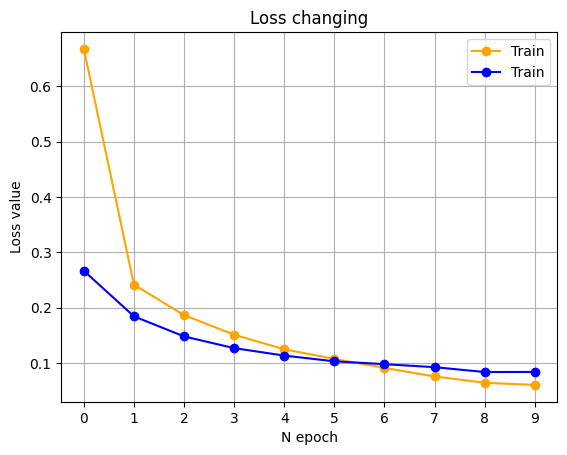

In [21]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(1, 1)

x_loss = np.arange(len(loss_train))
ax1.plot(x_loss,
         loss_train,
         marker='o',
         color='orange',
         label='Train'
        )

ax1.plot(x_loss,
         loss_val,
         marker='o',
         color='blue',
         label='Train'
        )

ax1.set_title('Loss changing')
ax1.set_xticks(x_loss)
ax1.set_xlabel('N epoch')
ax1.set_ylabel('Loss value')
ax1.grid(True)

plt.legend()
plt.show()

# ✅ Submit

In [22]:
test_preds = predict_test(model_trained, test)
test_preds.shape

(28000,)

In [23]:
submission = pd.DataFrame({
    'ImageId': np.arange(1, len(test_preds) + 1),
    'Label': test_preds.astype(int)
})

submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,4
4,5,3


In [25]:
submission.to_csv('submission.csv', index=False)

In [ ]:
pd.read_csv('submission.csv').head()

In [26]:
! kaggle competitions submit -c digit-recognizer -f submission.csv -m "mini autograd MLP submission"

100%|█████████████████████████████████████████| 208k/208k [00:01<00:00, 175kB/s]
Successfully submitted to Digit Recognizer